<a href="https://colab.research.google.com/github/thxlopez7/Analisis_Evasion_Clientes_Parte_2/blob/main/Telecom_X_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Carga de datos
df = pd.read_csv('datos_tratados.csv')

# Eliminación de identificador único
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Validación de estructura
print(f"Dimensiones: {df.shape}")
df.info()

Dimensiones: (7043, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Abandono           7043 non-null   object 
 1   Genero             7043 non-null   object 
 2   SeniorCitizen      7043 non-null   int64  
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Meses_Antiguedad   7043 non-null   int64  
 6   PhoneService       7043 non-null   object 
 7   MultipleLines      7043 non-null   object 
 8   Servicio_Internet  7043 non-null   object 
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Tipo_Contrato      7043 non-null   object 
 16  

In [12]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos de entrenamiento (balanceados)
# Usamos fit_transform en train y solo transform en test para evitar fuga de información
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Datos estandarizados correctamente.")
print(f"Media de la primera columna: {X_train_scaled[:,0].mean():.2f}")
print(f"Desviación estándar: {X_train_scaled[:,0].std():.2f}")

Datos estandarizados correctamente.
Media de la primera columna: -0.00
Desviación estándar: 1.00


In [3]:
# Lista de columnas que no aportan valor predictivo o son redundantes
columnas_irrelevantes = ['customerID', 'Abandono']

# Ejecución de la limpieza
df = df.drop(columns=[col for col in columnas_irrelevantes if col in df.columns])

# Verificación de columnas finales
print(f"Variables restantes ({len(df.columns)}):")
print(df.columns.tolist())

Variables restantes (21):
['Genero', 'SeniorCitizen', 'Partner', 'Dependents', 'Meses_Antiguedad', 'PhoneService', 'MultipleLines', 'Servicio_Internet', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Tipo_Contrato', 'PaperlessBilling', 'PaymentMethod', 'Factura_Mensual', 'Factura_Total', 'Cuentas_Diarias', 'Abandono_Binario']


In [4]:
import pandas as pd

# Asegurar que Factura_Total sea numérica
df['Factura_Total'] = pd.to_numeric(df['Factura_Total'], errors='coerce').fillna(0)

# Aplicar One-Hot Encoding a todas las variables categóricas
df_final = pd.get_dummies(df, drop_first=True)

# Verificación de la nueva estructura
print(f"Nuevas dimensiones: {df_final.shape}")
print(df_final.dtypes.value_counts())
df_final.head()

Nuevas dimensiones: (7043, 32)
bool       26
int64       3
float64     3
Name: count, dtype: int64


,SeniorCitizen,Meses_Antiguedad,Factura_Mensual,Factura_Total,Cuentas_Diarias,Abandono_Binario,Genero_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.19,0,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,2.00,0,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.46,1,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.27,1,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.80,1,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


Distribución de Clientes:
Permanecen (0): 5174 (73.46%)
Cancelaron (1): 1869 (26.54%)


/tmp/ipykernel_438/864299004.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abandono_Binario', data=df_final, palette='viridis')


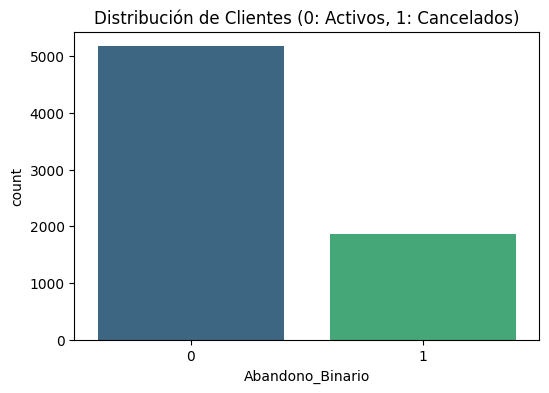

In [6]:
# Cálculo de frecuencias y proporciones
counts = df_final['Abandono_Binario'].value_counts()
percentages = df_final['Abandono_Binario'].value_counts(normalize=True) * 100

print("Distribución de Clientes:")
print(f"Permanecen (0): {counts[0]} ({percentages[0]:.2f}%)")
print(f"Cancelaron (1): {counts[1]} ({percentages[1]:.2f}%)")

# Visualización del desbalance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Abandono_Binario', data=df_final, palette='viridis')
plt.title('Distribución de Clientes (0: Activos, 1: Cancelados)')
plt.show()

In [7]:
# Verificación de columnas generadas por One-Hot Encoding
print("Muestra de columnas codificadas:")
print(df_final.filter(regex='Tipo_Contrato|PaymentMethod|Servicio_Internet').columns.tolist())

# Confirmación de que no quedan tipos 'object'
print(f"\nTipos de datos restantes:\n{df_final.dtypes.value_counts()}")

Muestra de columnas codificadas:
['Servicio_Internet_Fiber optic', 'Servicio_Internet_No', 'Tipo_Contrato_One year', 'Tipo_Contrato_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Tipos de datos restantes:
bool       26
int64       3
float64     3
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Definir variables X (características) e y (objetivo)
X = df_final.drop('Abandono_Binario', axis=1)
y = df_final['Abandono_Binario']

# 2. División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Aplicar SMOTE para balancear la clase minoritaria
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Verificación de resultados
print(f"Original y_train: {Counter(y_train)}")
print(f"Balanceado y_train_res: {Counter(y_train_res)}")

Original y_train: Counter({0: 4139, 1: 1495})
Balanceado y_train_res: Counter({0: 4139, 1: 4139})


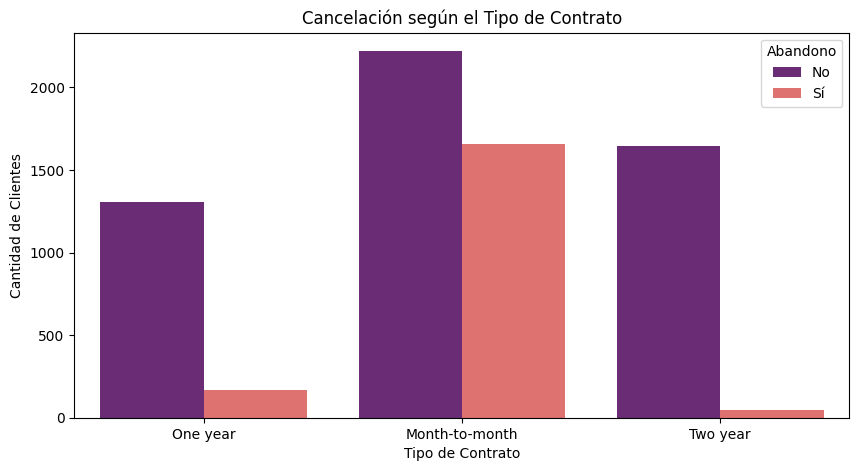

/tmp/ipykernel_438/3099236250.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono_Binario', y='Factura_Total', palette='viridis')


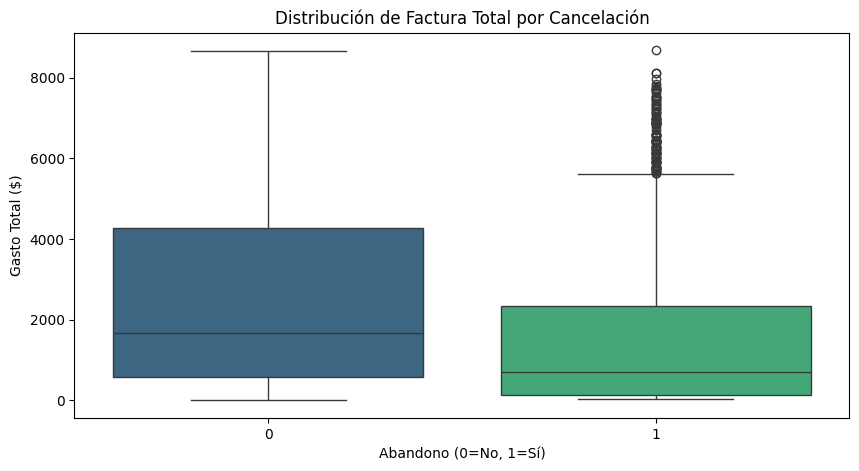

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Relación: Tipo de Contrato vs Cancelación
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Tipo_Contrato', hue='Abandono_Binario', palette='magma')
plt.title('Cancelación según el Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Abandono', labels=['No', 'Sí'])
plt.show()

# 2. Relación: Factura Total vs Cancelación
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Abandono_Binario', y='Factura_Total', palette='viridis')
plt.title('Distribución de Factura Total por Cancelación')
plt.xlabel('Abandono (0=No, 1=Sí)')
plt.ylabel('Gasto Total ($)')
plt.show()

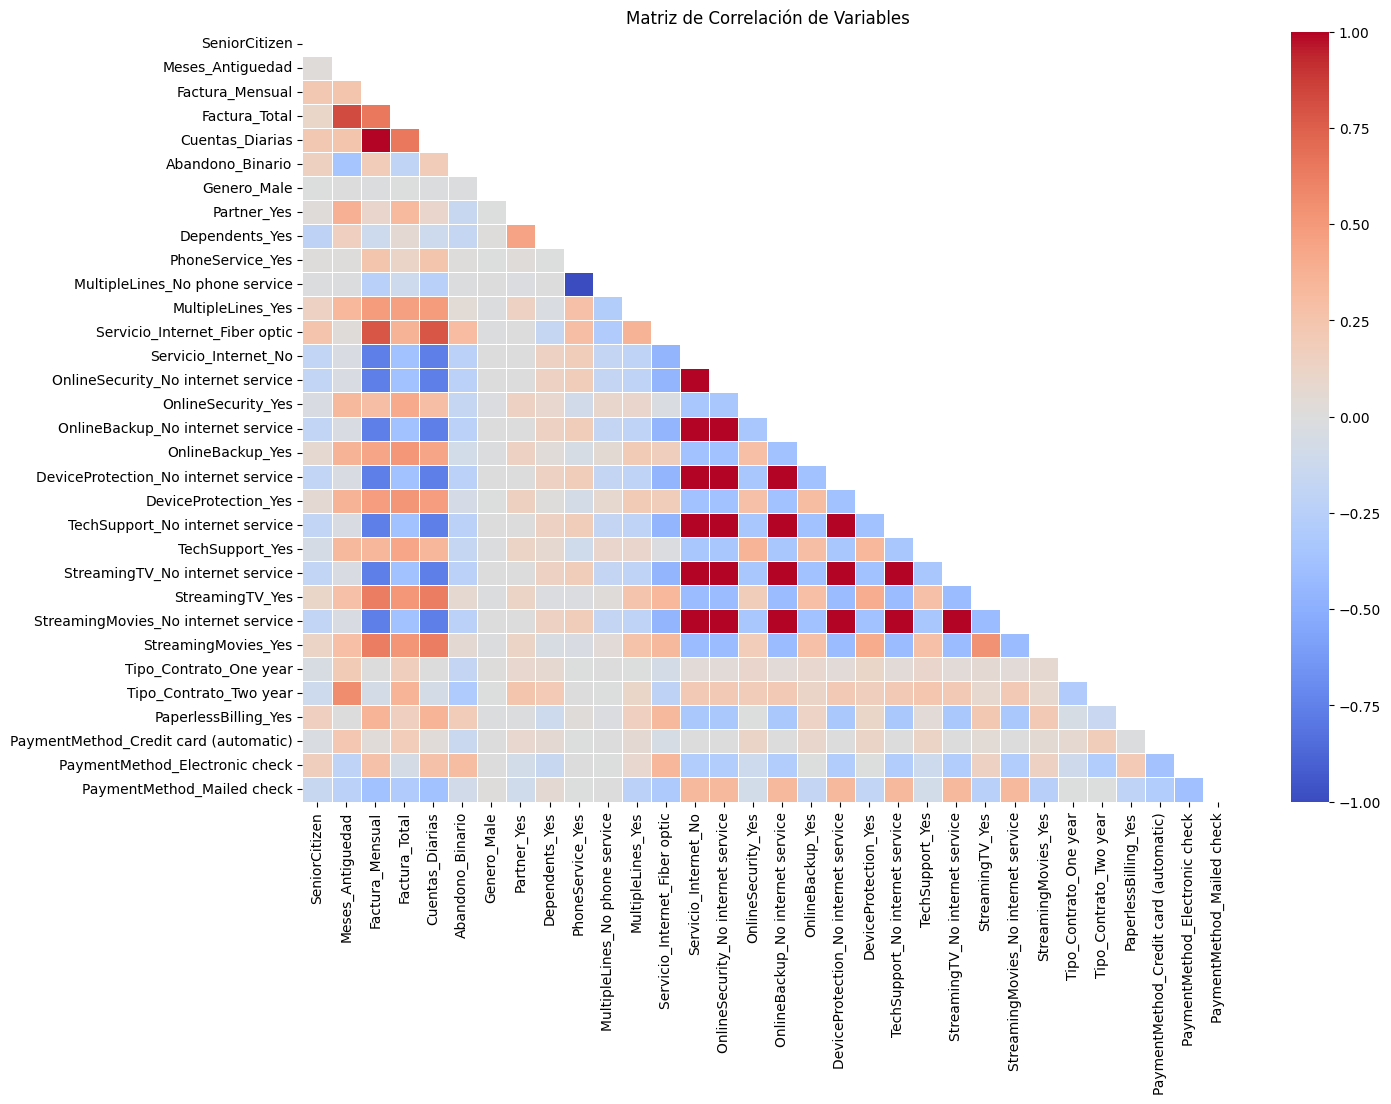

Correlación directa con Abandono_Binario:
Abandono_Binario                         1.000000
Servicio_Internet_Fiber optic            0.308020
PaymentMethod_Electronic check           0.301919
Cuentas_Diarias                          0.193412
Factura_Mensual                          0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
Genero_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupp

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos las variables numéricas y las más relevantes para no saturar el gráfico
plt.figure(figsize=(15, 10))

# Calculamos la matriz de correlación
corr_matrix = df_final.corr()

# Creamos una máscara para ver solo la mitad inferior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Mapa de calor
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

# Extraer específicamente la relación con la variable objetivo
print("Correlación directa con Abandono_Binario:")
print(corr_matrix['Abandono_Binario'].sort_values(ascending=False))

In [13]:
from sklearn.model_selection import train_test_split

# 1. Definir X (características) e y (objetivo)
X = df_final.drop('Abandono_Binario', axis=1)
y = df_final['Abandono_Binario']

# 2. División: 80% entrenamiento, 20% prueba
# stratify asegura que el 26.5% de abandonos esté presente en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Verificación de volúmenes
print(f"Total de registros: {len(df_final)}")
print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Set de Prueba (X_test): {X_test.shape[0]} muestras")

# 4. Verificación de la proporción de la clase objetivo
print("\nProporción de Abandono en Entrenamiento:")
print(y_train.value_counts(normalize=True))

Total de registros: 7043
Set de Entrenamiento (X_train): 5634 muestras
Set de Prueba (X_test): 1409 muestras

Proporción de Abandono en Entrenamiento:
Abandono_Binario
0    0.734647
1    0.265353
Name: proportion, dtype: float64


#Modelo 1: Regresión Logística (Requiere Normalización)

--- RESULTADOS: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1035
           1       0.57      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409



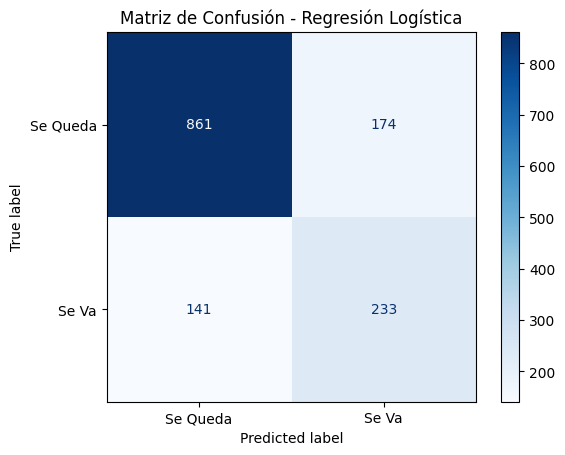

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Creamos el main de la Regresión Logística
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

# 2. Lo entrenamos con los datos escalados y balanceados
# Usamos X_train_scaled (ormalizado) y y_train_res (balanceado con SMOTE)
modelo_logistico.fit(X_train_scaled, y_train_res)

# 3. Ponemos a prueba al modelo con datos que NO conoce (X_test_scaled)
y_pred_log = modelo_logistico.fit(X_train_scaled, y_train_res).predict(X_test_scaled)

# 4. Resultados básicos
print("--- RESULTADOS: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

# Visualizar la Matriz de Confusión (El mapa de aciertos y errores)
disp = ConfusionMatrixDisplay.from_estimator(modelo_logistico, X_test_scaled, y_test, cmap='Blues', display_labels=['Se Queda', 'Se Va'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# Modelo 2: Random Forest

--- RESULTADOS: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.58      0.56      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.78      0.77      1409



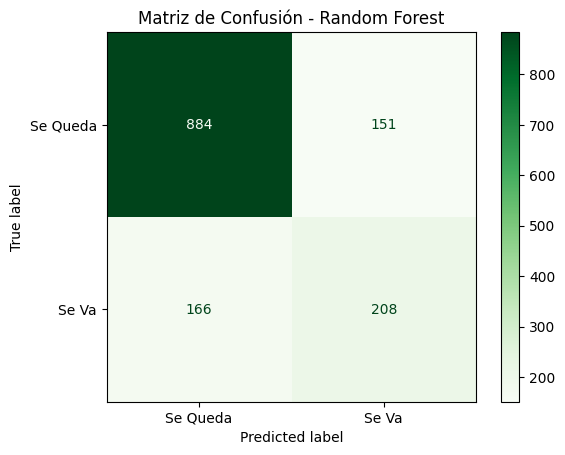

In [15]:
from sklearn.ensemble import RandomForestClassifier

# 1. Creamos el modelo (este no necesita los datos escalados)
modelo_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenamos con los datos BALANCEADOS originales (X_train_res)
modelo_forest.fit(X_train_res, y_train_res)

# 3. Predicción sobre el set de prueba original (X_test)
y_pred_rf = modelo_forest.predict(X_test)

# 4. Resultados
print("--- RESULTADOS: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# Matriz de Confusión
disp_rf = ConfusionMatrixDisplay.from_estimator(modelo_forest, X_test, y_test, cmap='Greens', display_labels=['Se Queda', 'Se Va'])
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [16]:
# Función para comparar Entrenamiento vs Prueba
def diagnostico_salud(modelo, nombre, X_train_input, y_train_input, X_test_input, y_test_input):
    train_score = modelo.score(X_train_input, y_train_input)
    test_score = modelo.score(X_test_input, y_test_input)

    print(f"--- Diagnóstico: {nombre} ---")
    print(f"Precisión en Entrenamiento: {train_score:.4f}")
    print(f"Precisión en Prueba (Test): {test_score:.4f}")
    print(f"Diferencia: {abs(train_score - test_score):.4f}")

    if train_score > test_score + 0.10:
        print("ALERTA: Posible Overfitting (Memorización).")
    elif train_score < 0.70:
        print("ALERTA: Posible Underfitting (Modelo muy simple).")
    else:
        print("ESTADO: Modelo equilibrado y saludable.")
    print("-" * 30)

# Ejecutar diagnóstico
diagnostico_salud(modelo_logistico, "Regresión Logística", X_train_scaled, y_train_res, X_test_scaled, y_test)
diagnostico_salud(modelo_forest, "Random Forest", X_train_res, y_train_res, X_test, y_test)

--- Diagnóstico: Regresión Logística ---
Precisión en Entrenamiento: 0.8350
Precisión en Prueba (Test): 0.7764
Diferencia: 0.0585
ESTADO: Modelo equilibrado y saludable.
------------------------------
--- Diagnóstico: Random Forest ---
Precisión en Entrenamiento: 0.9984
Precisión en Prueba (Test): 0.7750
Diferencia: 0.2234
ALERTA: Posible Overfitting (Memorización).
------------------------------


/tmp/ipykernel_438/3159096388.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


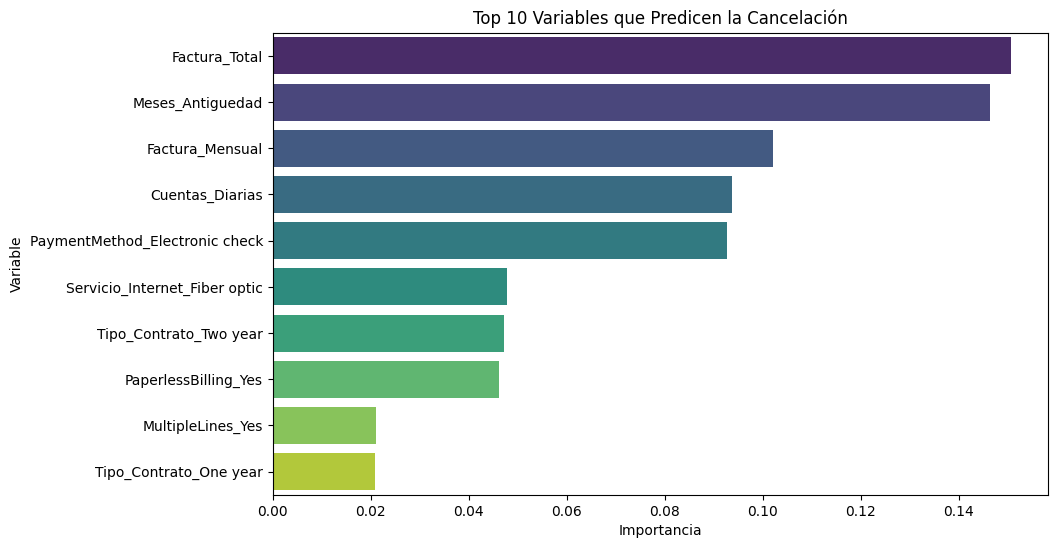

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraer importancia de las variables del Random Forest
importancias = modelo_forest.feature_importances_
columnas = X.columns

# Crear un DataFrame para visualizarlo mejor
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10 Variables que Predicen la Cancelación')
plt.show()

/tmp/ipykernel_438/3462660689.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancias_lr.head(10), ax=ax[0], palette='coolwarm')
/tmp/ipykernel_438/3462660689.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), ax=ax[1], palette='viridis')


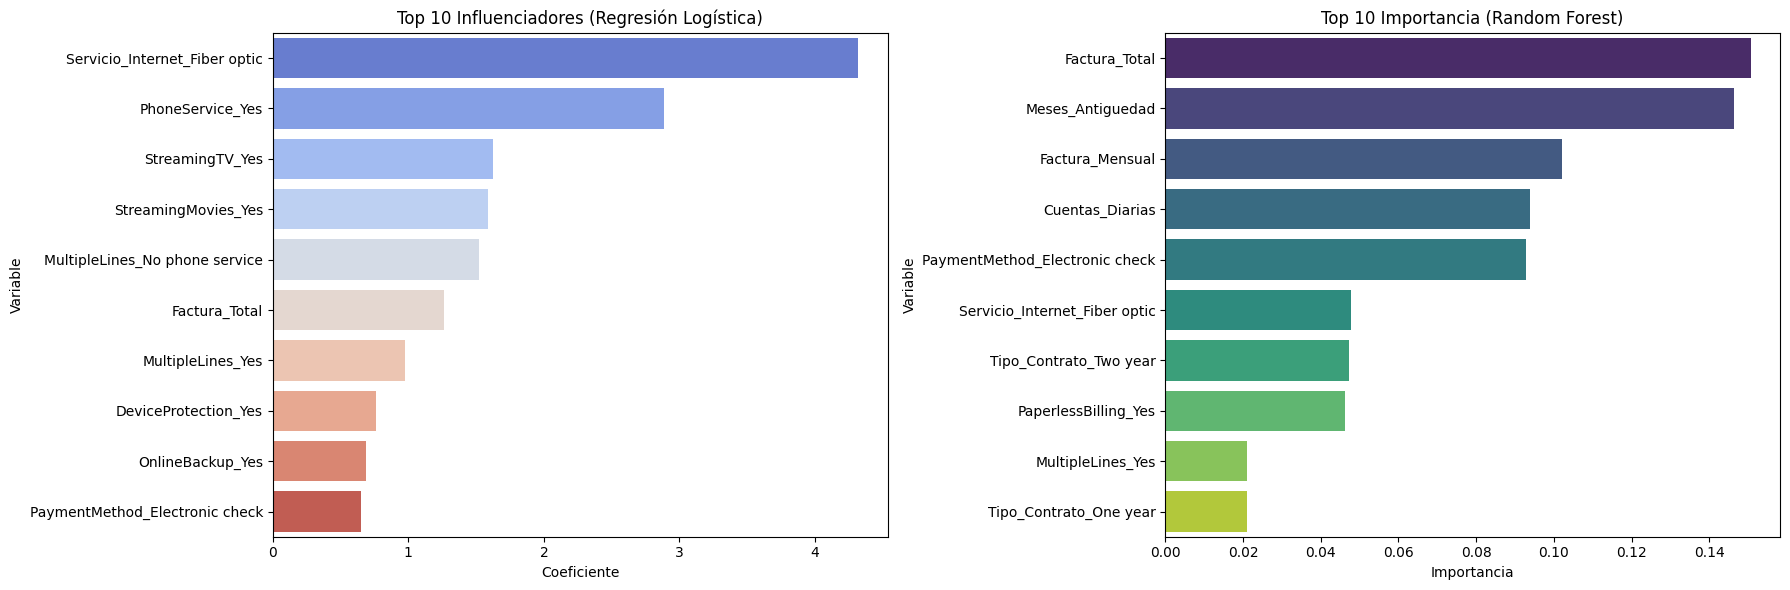

In [18]:
import numpy as np

#  1. Importancia en Regresión Logística (Coeficientes)
# Los coeficientes indican cuánto cambia la probabilidad de Churn por cada unidad de la variable.
importancias_lr = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

#  2. Importancia en Random Forest (Gini Importance)
# Mide cuánto reduce cada variable la incertidumbre (impureza) en los nodos de los árboles.
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_forest.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Graficar ambos
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Coeficiente', y='Variable', data=importancias_lr.head(10), ax=ax[0], palette='coolwarm')
ax[0].set_title('Top 10 Influenciadores (Regresión Logística)')

sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), ax=ax[1], palette='viridis')
ax[1].set_title('Top 10 Importancia (Random Forest)')

plt.tight_layout()
plt.show()

# Informe Final: Análisis de Retención y Predicción de Churn (Cancelación)

## 1. Introducción

El objetivo de este proyecto fue identificar los patrones que llevan a los clientes de una empresa de telecomunicaciones a cancelar su servicio y desarrollar un modelo de Machine Learning capaz de predecir este comportamiento con precisión.

El dataset analizado cuenta con 7.043 registros e incluye variables demográficas, de servicios y financieras.

---

## 2. Preprocesamiento de Datos y Estrategia

Para garantizar un desempeño óptimo de los modelos, se realizaron los siguientes pasos:

### Limpieza de Datos
- Tratamiento de valores nulos en `TotalCharges`.
- Eliminación de registros duplicados.

### Ingeniería de Variables
- Transformación de variables categóricas (como tipo de internet y tipo de contrato) en variables numéricas mediante One-Hot Encoding.

### Balanceo de Clases (SMOTE)
- Dado que solo el 26,5% de los clientes cancelan el servicio, se generaron datos sintéticos en el conjunto de entrenamiento.
- Este procedimiento evitó el sesgo del modelo hacia la clase mayoritaria (clientes que no cancelan).

### Escalado
- Normalización de variables numéricas como facturación y antigüedad.
- Paso necesario para modelos sensibles a la magnitud de las variables, como la Regresión Logística.

---

## 3. Evaluación y Comparativa de Modelos

Se evaluaron dos modelos con enfoques matemáticos diferentes con el fin de identificar el mejor equilibrio entre precisión y capacidad de generalización.

### Resultados de Métricas

| Métrica | Regresión Logística (Escalada) | Random Forest |
|----------|--------------------------------|---------------|
| Exactitud (Accuracy) | 78% | 77% |
| Precisión (Clase 1) | 0.57 | 0.58 |
| Recall (Detección de Fugas) | 62% | 56% |
| F1-Score | 0.59 | 0.57 |

### Análisis de Rendimiento

#### Modelo Seleccionado: Regresión Logística

- Recall del 62%, lo que implica que identifica 6 de cada 10 clientes que efectivamente cancelan.
- En la matriz de confusión obtuvo 233 verdaderos positivos frente a 208 del Random Forest.

#### Diagnóstico de Generalización

- Regresión Logística:
  - Accuracy en entrenamiento: 83,5%.
  - Accuracy en prueba: 77,6%.
  - Presenta una diferencia moderada, lo que indica buena capacidad de generalización.

- Random Forest:
  - Accuracy en entrenamiento: 99,8%.
  - Evidencia un overfitting severo, lo que indica memorización de los datos de entrenamiento y menor rendimiento en datos nuevos.

---

## 4. Factores que Influyen en la Cancelación

A partir del análisis de importancia de variables y coeficientes del modelo, se identificaron los principales factores asociados al abandono del servicio:

### Antigüedad (Tenure)
Es el factor más determinante. Los clientes con menos de 6 meses presentan una probabilidad significativamente mayor de cancelación en comparación con clientes con mayor permanencia.

### Cargos Financieros
Tanto la Factura_Mensual como la Factura_Total influyen de manera relevante. Se observa la existencia de un umbral de precio a partir del cual el cliente deja de percibir valor en el servicio.

### Tipo de Servicio
Los usuarios de Fibra Óptica presentan mayor tasa de cancelación que los de DSL, lo que sugiere posibles problemas de percepción de valor, estabilidad o estructura de costos.

### Método de Pago
El uso de Cheque Electrónico se asocia con mayor probabilidad de cancelación, mientras que los métodos de pago automáticos favorecen la retención.

---

## 5. Estrategias de Retención Propuestas

Con base en la evidencia obtenida, se proponen las siguientes acciones:

### Fidelización Temprana
Implementar un programa de onboarding estructurado para los primeros 3 a 6 meses, incluyendo incentivos progresivos por permanencia.

### Incentivo a Contratos de Largo Plazo
Ofrecer reducción en la factura mensual a clientes con contrato mes a mes que migren a planes anuales o bianuales.

### Revisión del Servicio de Fibra Óptica
Evaluar calidad técnica y estructura de precios, dado su alto impacto en la cancelación.

### Migración de Métodos de Pago
Incentivar el cambio desde Cheque Electrónico hacia Débito Automático mediante un beneficio económico puntual.

---

## 6. Conclusión General

La Regresión Logística, correctamente escalada y balanceada, demostró ser una herramienta eficaz para la predicción del churn.

El modelo permite identificar aproximadamente el 62% de los clientes en riesgo de cancelación, lo que habilita estrategias proactivas de retención, optimización de recursos comerciales y aumento del Lifetime Value (LTV).